In [1]:
import os
os.chdir("PyTorch_PiNN_for_Poisson_convection_equations_system/")

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import time

from tqdm import tqdm

import programs.NN as NN
import programs.visualize as vis
import programs.misc as misc
import programs.objects as obj

from programs.PINN import *
from programs.misc import *

In [3]:
!nvidia-smi

Thu Oct  9 14:38:07 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 4000                On  |   00000000:01:00.0 Off |                  N/A |
| 30%   35C    P8              5W /  125W |    2587MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
torch.manual_seed(1234)
np.random.seed(1234)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device='cpu'
if device!='cpu':
    torch.cuda.set_device(device)
print(device)

torch.cuda.empty_cache()

print(torch.cuda.get_device_name(0))
print(torch.cuda.memory_allocated(0) / 1024**2, "MB allocated")
print(torch.cuda.memory_reserved(0) / 1024**2, "MB reserved")

cuda:0
Quadro RTX 4000
0.0 MB allocated
0.0 MB reserved


In [5]:
# Максимальная концентрация проппанта
cmax = 0.65

# Концентрация входящего проппанта в первый момент времени
c1 = 0.25 / cmax

# Концентрация входящего проппанта во второй момент времени
c2 = 0.0 / cmax

c_condition = [c1, c2]

# Интервалы смены концентрации
transitional_times = [0.5]

# Длина интервала перфорации
chi = 0.5

# Степень в вязкости
beta = -2.5

# Число точек для ГУ (возводится в квадрат)
BC_points = 64

# Число точек для НУ (возводится в квадрат)
IC_points = 64

# Число точек коллокации (возводится в куб)
PDE_points = 32

# Геометрия
L = 1
H = 1
T = 1

In [6]:
data = {'alpha' : L / H,
        'zeta'  : chi / H,
        'kappa' : 1 / L,
        'beta'  : beta,
        'ratio' : 10,
        't_max' : T,
        'times' : transitional_times,
        'c_cond': c_condition,
        'N_PDE' : PDE_points,
        'N_BC'  : BC_points,
        'N_IC'  : IC_points,
        'w_func': 'const',
        'IC_const': 0.0,
        'save_after': True,
        'lr': 1e-5,
        'data_path': "data/test/",
        'data_shape': [101, 101, 101],
        'batch_size': 16384,
        'k':1,
        # 'w1': 0,
        # 'w2': 0.5,
        # 'path' : 'data/testIdea/',
        
        'NN_params' : {'input_size' : 3,
                       'neurons_arr': [48]*6,
                       'output_size' : 3,
                       'depth':5,
                       'act':'Morlet'
                      }
        }

net = Poisson_Convection(data, device=device)
net.model.apply(NN.Net.init_weights)
net.model

101 101 101


Net(
  (layers): Sequential(
    (input): Linear(in_features=3, out_features=48, bias=True)
    (input_activation): Morlet()
    (hidden_0): Linear(in_features=48, out_features=48, bias=True)
    (activation_0): Morlet()
    (hidden_1): Linear(in_features=48, out_features=48, bias=True)
    (activation_1): Morlet()
    (hidden_2): Linear(in_features=48, out_features=48, bias=True)
    (activation_2): Morlet()
    (hidden_3): Linear(in_features=48, out_features=48, bias=True)
    (activation_3): Morlet()
    (hidden_4): Linear(in_features=48, out_features=48, bias=True)
    (activation_4): Morlet()
    (output): Linear(in_features=48, out_features=3, bias=True)
  )
)

In [7]:
# net.updateFromFile("data/testIdea/14137", device=device)
# net.path = 'data/April/4'
# # net = net.load('data/February/14/52900')
# # vars(net)
# pass

In [8]:
# net.c_cond = [c1, c2, c1, c2]
# net.times = [0.5, 1, 1.5]
# net.t_max = 1.1
# net.beta = -0.0
# net.make_distributed_points()
# plt.grid()
# plt.scatter(net.t_BC.data.cpu(), net.c.data.cpu(), c=net.y_BC.data.cpu(), s=6, cmap='turbo')
# plt.colorbar()

In [ ]:
net.weights =  [1, 1, 1, 1, 1, 1, 0, 0]
net.Adam_epochs = 0
start_time = time.time()
net.max_epoch = 25000
net.max_iter = 1
# net.train()
for _ in tqdm(range(100)): net.make_distributed_points()
# net.train()
net.weights =  [1, 1, 1, 1, 1, 1, 0, 1]
net.train()
end_time = time.time()
elapsed_time = end_time - start_time

100%|██████████| 100/100 [00:06<00:00, 16.57it/s]


|     Epoch      |      PDE loss       |     p corr loss     |       IC loss       |       BC loss       |      Data loss      |    Summary loss     |      time      |
|     17811      |       0.00439       |       0.00350       |       0.00025       |       0.00550       |       0.00091       |       0.01455       |   342.494211   |
|     17812      |       0.00439       |       0.00350       |       0.00025       |       0.00550       |       0.00091       |       0.01455       |   22.153519    |
|     17813      |       0.00439       |       0.00350       |       0.00025       |       0.00550       |       0.00091       |       0.01455       |   22.075466    |
|     17814      |       0.00439       |       0.00350       |       0.00025       |       0.00550       |       0.00091       |       0.01455       |   22.105654    |
|     17815      |       0.00439       |       0.00350       |       0.00025       |       0.00550       |       0.00091       |       0.01455       |   22.2332

In [10]:
net.epoch

16802

RuntimeError: shape '[101, 101, 101]' is invalid for input of size 2050401

In [12]:
plt.imshow(cc[-1])
plt.colorbar()

NameError: name 'cc' is not defined

In [13]:
w0 = 1
mu0 = 0.01
cmax = 0.65

chi = 0.5
H = 1
L = net.alpha * H
u_in = net.kappa * L
T = net.t_max*net.kappa
# T = 1

pc = 12 * mu0 * u_in * L / w0**2 

Nx = 501
Ny = 501
Nt = int(101*T)
Nt = 3

x_Tensor = torch.linspace(0, 1, Nx)
y_Tensor = torch.linspace(0, 1, Ny)
t_Tensor = torch.linspace(0, T, Nt)

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)
t = np.linspace(0, T, Nt)

dx = L / (Nx - 1)
dy = H / (Ny - 1)

mesh_xy, mesh_yx = np.meshgrid(x,y)
mesh_ty, mesh_yt = np.meshgrid(t,y)

mesh_XYT = torch.stack(torch.meshgrid(x_Tensor,y_Tensor,t_Tensor, indexing='ij')).reshape(3, -1).T
mesh_X = mesh_XYT[:,0]
mesh_Y = mesh_XYT[:,1]
mesh_T = mesh_XYT[:,2]

K = net.N_BC
N = net.N_BC2
T

1.0

In [14]:
net.eval()

c, px, py, ux, uy, mu, conv, div, corr = [], [], [], [], [], [], [], [], []



for i in tqdm(t_Tensor):
    mesh_XYT = torch.stack(torch.meshgrid(x_Tensor,y_Tensor,i, indexing='ij')).reshape(3, -1).T
    X = torch.autograd.Variable(mesh_XYT[:,0], requires_grad=True).to(device)
    Y = torch.autograd.Variable(mesh_XYT[:,1], requires_grad=True).to(device)
    T = torch.autograd.Variable(mesh_XYT[:,2], requires_grad=True).to(device)

    c.append( net.get_c(X,Y,T).reshape(Nx,  Ny).transpose(1,0))
    px.append(net.get_px(X,Y,T).reshape(Nx, Ny).transpose(1,0))
    py.append(net.get_py(X,Y,T).reshape(Nx, Ny).transpose(1,0))
    ux.append(net.get_ux(X,Y,T).reshape(Nx, Ny).transpose(1,0))
    uy.append(net.get_uy(X,Y,T).reshape(Nx, Ny).transpose(1,0))
    # conv.append(net.get_conv(X,Y,T).reshape(Nx, Ny).transpose(1,0) / (net.w_func(X,Y).max()**3).data.cpu().numpy())
    # div.append(net.get_div(X,Y,T).reshape(Nx, Ny).transpose(1,0) / (net.w_func(X,Y).max()**3).data.cpu().numpy())
    # corr.append(net.get_corr(X,Y,T).reshape(Nx, Ny).transpose(1,0))

# for i in tqdm(y_Tensor):
#     mesh_XYT = torch.stack(torch.meshgrid(x_Tensor,i,t_Tensor, indexing='ij')).reshape(3, -1).T
#     X = torch.autograd.Variable(mesh_XYT[:,0], requires_grad=True)
#     Y = torch.autograd.Variable(mesh_XYT[:,1], requires_grad=True)
#     T = torch.autograd.Variable(mesh_XYT[:,2], requires_grad=True)
#     BETA = torch.autograd.Variable(net.beta*torch.ones_like(X), requires_grad=True)

#     c.append(net.get_c(X,Y,T,BETA).reshape(Ny,Nt).transpose(1,0))

c = np.array(c) * cmax
px = np.array(px) * pc
py = np.array(py) * pc
ux = np.array(ux) * u_in
uy = np.array(uy) * u_in
conv = np.array(conv)
cx = np.array(conv)
div = np.array(div)
corr = np.array(corr)
total = net.weights[0]*np.abs(conv) + net.weights[1]*np.abs(div) + net.weights[2]*np.abs(corr)

100%|██████████| 3/3 [00:00<00:00,  9.87it/s]


In [15]:
k = -1
# print (solver.times[k])

try: all_c = list(c) + list((solver.Q[k]/solver.w).reshape(1,M,M)) #[-1].reshape(1,N,N)
except: all_c = list(c)
try: all_ux = list(ux) + list(solver.Vx[k].reshape(1,M,M+1))
except: all_ux = list(ux)
try: all_uy = list(uy) + list(solver.Vy[k].reshape(1,M+1,M))
except: all_uy = list(uy)

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

def plot_results(data,
                 N: int,
                 limits: list,
                 path: str = '',
                 cmaps: list = None,
                 title: list = None,
                 lims: list = None,
                 cbar_labels: list = None,
                 tick_step: float = 0.25
                 ):
    """
    Plots data from Neural Network

    Parameters:
    -----------
    data : list[np.ndarray]
        List of M arrays, each shaped (N, H, W)
    N : int
        Number of rows in the plot grid
    limits : list[float]
        Plotting area limits [x_min, x_max, y_min, y_max]
    path : str
        Path to save the figure
    cmaps : list[str]
        List of colormaps per column (length M)
    title : list[list[str]]
        Titles for each subplot, shape (M, N)
    lims : list[list[float]]
        List of [vmin, vmax] per column (length M)
    cbar_labels : list[str]
        Labels for colorbars (length M)
    tick_step : float
        Tick step on both axes
    """

    x_min, x_max, y_min, y_max = limits
    M = len(data)

    if cmaps is None:
        cmaps = ['turbo'] * M

    if cbar_labels is None:
        cbar_labels = [f'$f_{i}$' for i in range(1, M + 1)]

    if title is None:
        title = [[f'$f_{col}(x,y)$' for _ in range(N)] for col in range(M)]

    if lims is None:
        lims = [[np.min(data[col]), np.max(data[col])] for col in range(M)]

    height_ratios = []
    for i in range(2 * N - 1):
        if i % 2 == 0:
            height_ratios.append(1)
        elif i == 2 * N - 3:
            height_ratios.append(0.5 * N / (N + 1) + 0.5)
        else:
            height_ratios.append(0.5 * N / (N + 1))

    width_inches = M * 3
    height_inches = 2 * N + 0.5
    fig = plt.figure(figsize=(width_inches, height_inches), dpi=300)

    gs = gridspec.GridSpec(
        nrows=2 * N - 1,
        ncols=M,
        height_ratios=height_ratios,
        hspace=0.0,
        wspace=0.4
    )

    im_list = []
    axes = [[None] * M for _ in range(N)]

    for row in range(N):
        for col in range(M):
            ax = fig.add_subplot(gs[row * 2, col])
            im = ax.imshow(data[col][row], cmap=cmaps[col],
                           vmin=lims[col][0], vmax=lims[col][1],
                           extent=[x_min, x_max, y_max, y_min])
            ax.set_title(title[col][row], fontsize=9, pad=6)
            ax.invert_yaxis()
            ax.set_xlabel('x, м', fontsize=8)
            ax.set_ylabel('y, м', fontsize=8)
            ax.set_xticks(np.arange(x_min, x_max + tick_step, tick_step))
            ax.set_yticks(np.arange(y_min, y_max + tick_step, tick_step))
            ax.tick_params(axis='both', which='major', labelsize=5)
            ax.grid(color='lightgrey', alpha=0.5, linewidth=0.5)
            axes[row][col] = ax
            im_list.append(im)

    for col in range(M):
        ax_last = axes[N - 1][col]
        ax_prev = axes[N - 2][col]

        pos_last = ax_last.get_position()
        pos_prev = ax_prev.get_position()

        center_y = (pos_last.y0 + pos_prev.y1) / 2
        height = 0.012

        cax = fig.add_axes([pos_last.x0, center_y - height / 2, pos_last.width, height])
        cbar = fig.colorbar(im_list[(N - 1) * M + col], cax=cax, orientation='horizontal')
        cax.set_xlabel(cbar_labels[col], fontsize=8, labelpad=2)
        cax.tick_params(labelsize=6)

    plt.show()

    if path:
        fig.savefig(path, bbox_inches='tight')


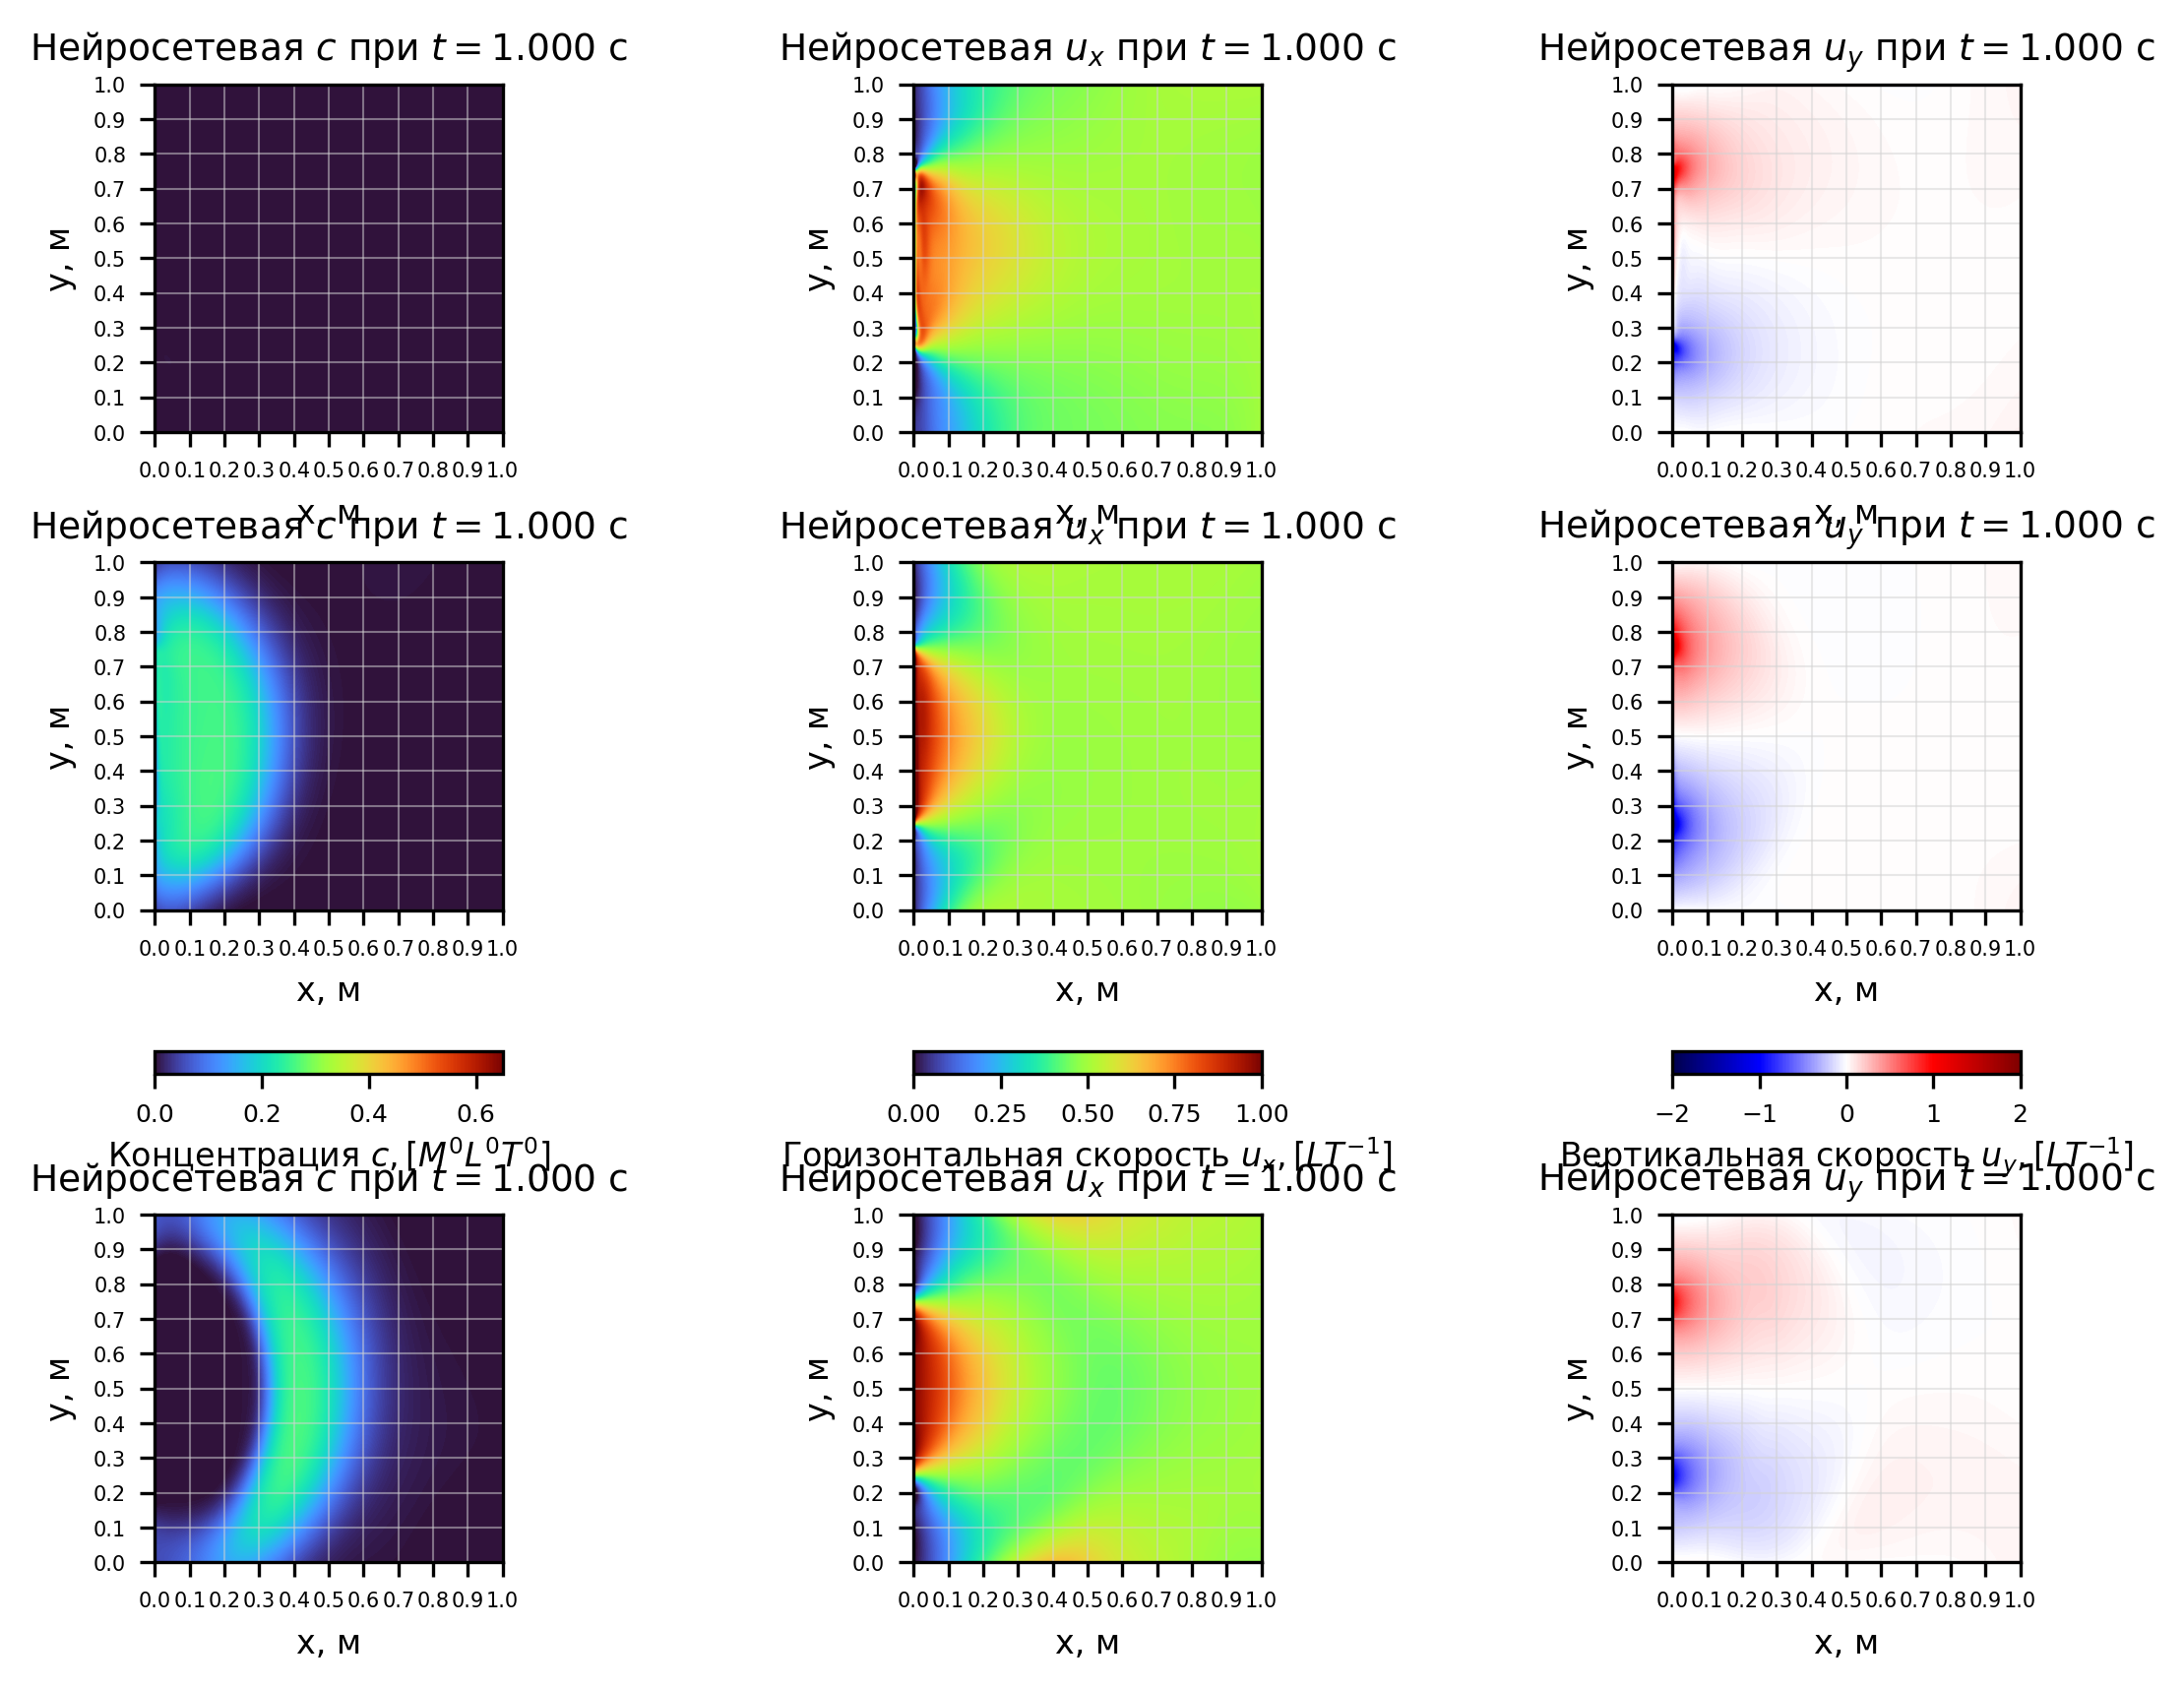

In [16]:
data = [all_c, all_ux, all_uy]
lims=[[0,cmax], [0,u_in], [-2,2]]
# labels = ['Concentration $c, [M^0L^0T^0]$', 'Horizontal velocity $u_x, [L T^{-1}]$', 'Vertical velocity $u_y, [L T^{-1}]$']
labels = ['Концентрация $c, [M^0L^0T^0]$', 'Горизонтальная скорость $u_x, [L T^{-1}]$', 'Вертикальная скорость $u_y, [L T^{-1}]$']
# data = [c, px, py]
# lims=[[0,cmax], [0,1], [-2,2]]
# data = [conv, div, corr]
# lims=[[0,cmax], [0,1], [-2,2]]
titles = [[f'Нейросетевая $c$ при $t=${1.:.3f} с' for i in t]   + [f'Численная $c$ при $t={t[-1]:.3f} с$'],
          [f'Нейросетевая $u_x$ при $t=${1.:.3f} с' for i in t] + [f'Численная $u_x$ при $t={t[-1]:.3f} с$'],
          [f'Нейросетевая $u_y$ при $t=${1.:.3f} с' for i in t] + [f'Численная $u_y$ при $t={t[-1]:.3f} с$']]
# titles = [[f'Neural $c$ at $t=${t[-1]}'] + [f'True $c$ at $t={t[-1]}$'], [f'Neural $u_x$ at $t=${t[-1]}'] + [f'True $u_x$ at $t={t[-1]}$'], [f'Neural $u_y$ at $t=${t[-1]}'] + [f'True $u_y$ at $t={t[-1]}$']]
plot_results(data=data, N=len(data[0]), limits=[0, L, 0, H], title=titles, cmaps=['turbo','turbo','seismic'], lims=lims, cbar_labels=labels, tick_step=0.1)
pass

In [ ]:
net.save(net.path)

In [ ]:
net.epoch

In [ ]:
net.NN_params['act']         = net.act_dict.get(data.setdefault('NN_params', {1:1}).setdefault('act', None))# 

In [ ]:
fig = plt.figure(dpi=200)
# err = np.abs(c[0] - np.where(mesh_yx==0, net.c_cond[0], 0)*np.where(np.abs(mesh_xy - H/2)<=chi/2, 1, 0))
# plt.imshow(np.where(err-0>0, err, np.nan), cmap='magma', extent=[0, L, H, 0])
# plt.colorbar()
# plt.gca().invert_yaxis()
plt.scatter(net.x_IC[0*net.N_IC**2:].data.cpu().numpy(), net.y_IC[0*net.N_IC**2:].data.cpu().numpy(), alpha=0.5, c='lime', edgecolors='white', s=7, linewidths=0.5)
plt.title('Распределение точек НУ')
pass

In [ ]:
try:
    print('Elapsed time: ', elapsed_time)
except NameError: pass